In [1]:
%load_ext autoreload

%autoreload 2

from reproducibility.reproducibility import *

# Toy examples

## Moon dataset

### Training

In [2]:
from scipy.stats import wasserstein_distance
K=1
H=0.9

runs = 1
wsd1 = torch.zeros(runs)
wsd2 = torch.zeros(runs)

for n in range(runs):
    AlignExperiment.run(f"--dataset=moon  --h_dim=64  --n_layers=2  --n_epochs=20  --reg_weight=1.  --timestep_emb_dim=32  --in_dim=2 --out_dim=2  --diffusivity_schedule=fbb  --max_diffusivity=.7 --H={H} --K={K} --use_drift_in_doobs=True  --activation=silu").save("moon_silu")

    moon = AlignExperiment.load("moon_silu")
    samples = moon.sample(samples_num=100000, trials_num=7)
    if len(samples.shape) == 4:
        samples = samples[:,:,:,0]

    marginals = moon.get_marginals(samples_num=100000)
    wsd1[n] = wasserstein_distance(samples[-1,:,0],marginals['final'][:,0])
    wsd2[n] = wasserstein_distance(samples[-1,:,1],marginals['final'][:,1])

print('wsd for d=1:', wsd1)
print('wsd for d=2:', wsd2)

mean_wsd1 = torch.mean(wsd1)
mean_wsd2 = torch.mean(wsd2)
mean_wsd_overall = (mean_wsd1 + mean_wsd2)/2

print('mean wsd for d=1', mean_wsd1)
print('mean wsd for d=2', mean_wsd2)
print('mean wsd overall', mean_wsd_overall)

config {'data_dir': 'moon', 'log_dir': '../reproducibility/moon/model', 'config': None, 'task': 'synthetic', 'wandb_entity': None, 'group_name': None, 'wandb_mode': 'online', 'job_type': 'dev-train', 'online': False, 'dataset': 'moon', 'n_samples': 10000, 'train_bs': 32, 'val_bs': 8, 'transform': None, 'split_fracs': [0.8, 0.1, 0.1], 'num_workers': 1, 'in_dim': 2, 'out_dim': 2, 'timestep_emb_dim': 32, 'h_dim': 64, 'n_layers': 2, 'activation': 'silu', 'dropout_p': 0.1, 'run_name': 'dlmvvwryi', 'n_epochs': 20, 'use_grad_noise': False, 'drift_weight': 1.0, 'reg_weight': 1.0, 'reg_weight_T': 1.0, 'reg_weight_t': 1.0, 'diffusivity_schedule': 'fbb', 'max_diffusivity': 0.7, 'H': 0.9, 'K': 1, 'use_drift_in_doobs': True, 'optim_name': 'adamw', 'lr': 0.001, 'weight_decay': 0.001, 'grad_clip_value': 10.0, 'scheduler': 'plateau', 'scheduler_mode': 'min', 'scheduler_patience': 10, 'ema_decay_rate': 0.999, 'log_every': 1000, 'eval_every': 10000, 'inference_every': 0, 'inference_steps': 100, 'inferen

/home/belova/Desktop/aligned_diffusion_bridges/sbalign/data/datasets.py:178: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_full = torch.load(filename, map_location=devi

Epoch 1: Training Loss: 4.9464 bb_loss 4.9154 reg_loss_T 0.0086 reg_loss_t 0.0225 
Epoch 1: Validation Loss: 0.5719 bb_loss 0.5714 reg_loss_T 0.0001 reg_loss_t 0.0005 

After best validation, saving model to ../reproducibility/moon/model/dlmvvwryi/best_model.pt
After best validation, saving ema to ../reproducibility/moon/model/dlmvvwryi/best_ema_model.pt

Saving last model to ../reproducibility/moon/model/dlmvvwryi/last_model.pt

Epoch 2: Training Loss: 34.7594 bb_loss 34.7559 reg_loss_T 0.0015 reg_loss_t 0.002 
Epoch 2: Validation Loss: 0.3347 bb_loss 0.3346 reg_loss_T 0.0 reg_loss_t 0.0001 

After best validation, saving model to ../reproducibility/moon/model/dlmvvwryi/best_model.pt
After best validation, saving ema to ../reproducibility/moon/model/dlmvvwryi/best_ema_model.pt

Saving last model to ../reproducibility/moon/model/dlmvvwryi/last_model.pt



KeyboardInterrupt: 

In [ ]:
moon = AlignExperiment.load("moon_silu")
samples = moon.sample(samples_num=100000, trials_num=7)
if len(samples.shape) == 4:
    samples = samples[:,:,:,0]

marginals = moon.get_marginals(samples_num=100000)
wsd1 = wasserstein_distance(samples[-1,:,0],marginals['final'][:,0])
wsd2 = wasserstein_distance(samples[-1,:,1],marginals['final'][:,1])

print('wsd for d=1:', wsd1)
print('wsd for d=2:', wsd2)

NameError: name 'AlignExperiment' is not defined

In [ ]:
for n in range(100):
    for d in range(2):
        print(wasserstein_distance(samples[n,:,d],marginals['final'][:,d]))

### Inference

In [ ]:
moon = AlignExperiment.load("moon_silu")

Args: {'data_dir': 'moon', 'log_dir': '../reproducibility/moon/model', 'config': None, 'task': 'synthetic', 'wandb_entity': None, 'group_name': None, 'wandb_mode': 'online', 'job_type': 'dev-train', 'online': False, 'dataset': 'moon', 'n_samples': 10000, 'train_bs': 32, 'val_bs': 8, 'transform': None, 'split_fracs': [0.8, 0.1, 0.1], 'num_workers': 1, 'in_dim': 2, 'out_dim': 2, 'timestep_emb_dim': 32, 'h_dim': 64, 'n_layers': 2, 'activation': 'silu', 'dropout_p': 0.1, 'run_name': 'qjoqovjql', 'n_epochs': 20, 'use_grad_noise': False, 'drift_weight': 1.0, 'reg_weight': 1.0, 'reg_weight_T': 1.0, 'reg_weight_t': 1.0, 'diffusivity_schedule': 'fbb', 'max_diffusivity': 0.7, 'H': 0.9, 'K': 1, 'use_drift_in_doobs': True, 'optim_name': 'adamw', 'lr': 0.001, 'weight_decay': 0.001, 'grad_clip_value': 10.0, 'scheduler': 'plateau', 'scheduler_mode': 'min', 'scheduler_patience': 10, 'ema_decay_rate': 0.999, 'log_every': 1000, 'eval_every': 10000, 'inference_every': 0, 'inference_steps': 100, 'inferenc

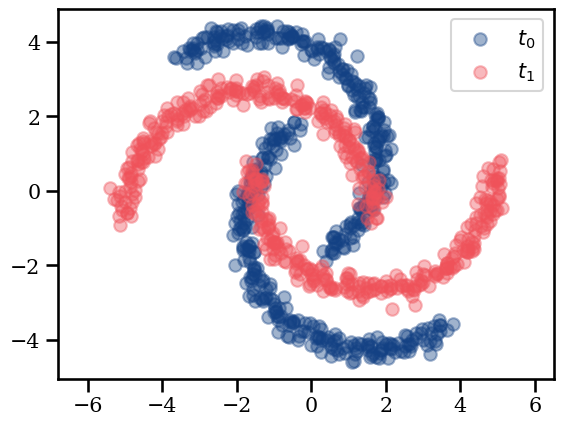

In [ ]:
plot_marginals(moon.get_marginals())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
samples shape (101, 500, 2, 2)


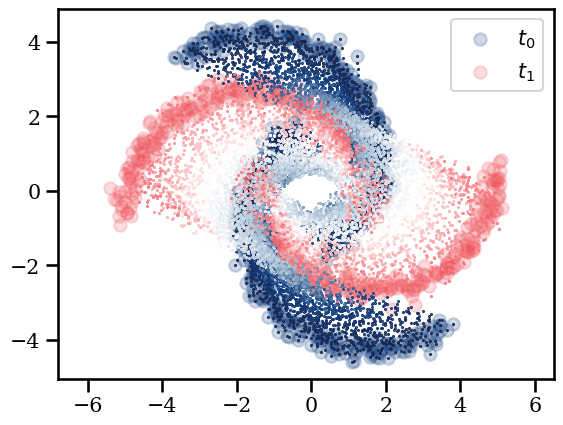

In [ ]:
%load_ext autoreload

%autoreload 2

plot_marginals(moon.get_marginals(), alpha=.2)

#print(.shape)
samples = moon.sample(samples_num=500, trials_num=7)
print('samples shape',samples.shape)
samples
if len(samples.shape) == 3:
    plot_multiple_marginals(samples, skip_step=4) 
else:
    plot_multiple_marginals(samples[:,:,:,0], skip_step=4)     
export_fig("fig_sb_align_moon_traj")

K=1


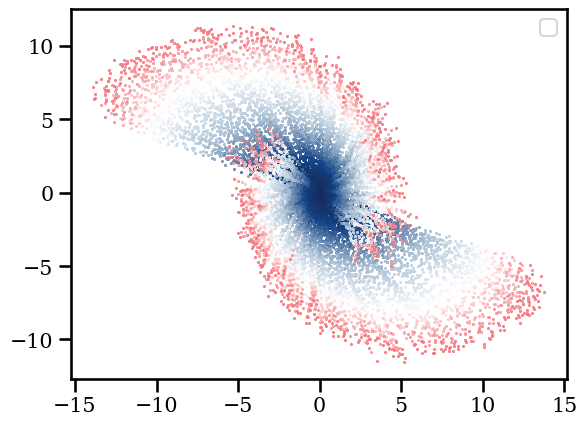

In [ ]:
for k in range(K):
    if len(samples.shape) == 4:
        print(f'K={k+1}')
        plot_multiple_marginals(samples[:,:,:,k+1], skip_step=4)
        plt.show()
        plt.close()


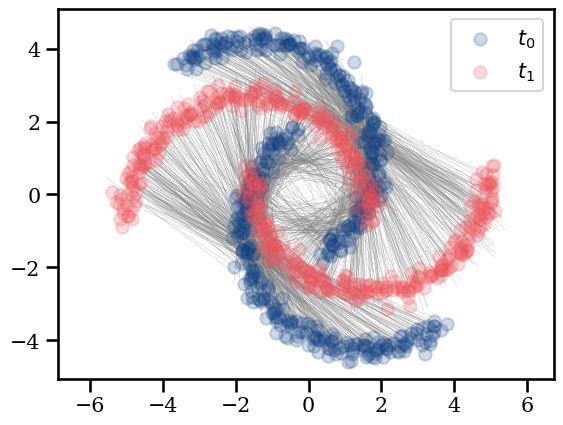

In [ ]:
plot_marginals(moon.get_marginals(), alpha=.2)


moon_sampled = moon.sample(samples_num=1000, trials_num=2)

if len(moon_sampled.shape) == 4:
    moon_sampled = moon_sampled[:,:,:,0]

#print('moon_sampled',moon_sampled.shape)
plot_matchings(*moon_sampled[[0,-1]])#plot_multiple_marginals(moon_sampled[[0,1,-2,-1]], skip_step=1, alpha=.9)

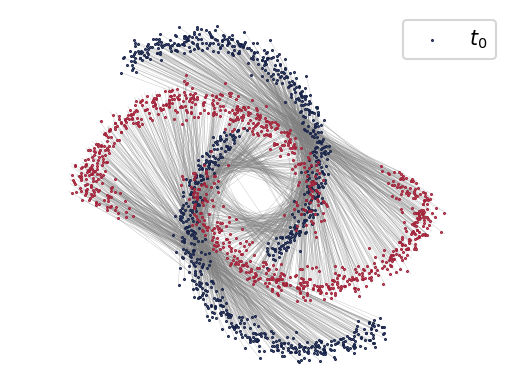

In [ ]:
plt.axis("off")
plt.axis("equal")

moon_sampled = moon.sample(samples_num=1000, trials_num=7)

if len(moon_sampled.shape) == 4:
    moon_sampled = moon_sampled[:,:,:,0]

plot_matchings(*moon_sampled[[0,-1]])
plot_multiple_marginals(moon_sampled, skip_step=99, labels=[r"$t_0$", r"$t_1$"], alpha=1)
export_fig("fig_sb_align_moon_match")

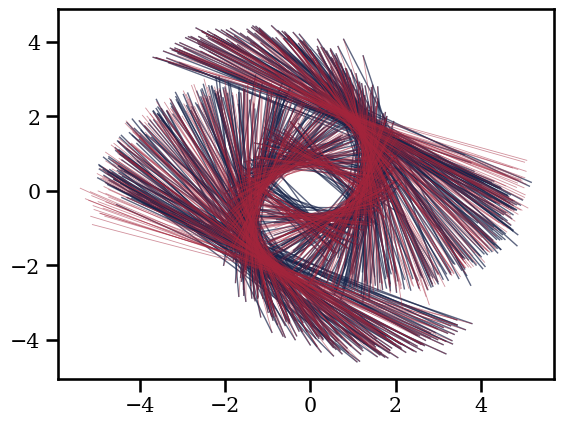

In [ ]:
moon_sampled = moon.sample(samples_num=500, trials_num=7)

if len(moon_sampled.shape) == 4:
    moon_sampled = moon_sampled[:,:,:,0]
    
plot_matchings(*moon_sampled[[0,-1]], color=palette[0], lw=1.)
plot_matchings(*moon.get_marginals().values(), color=palette[-1], lw=.6, alpha=.5)

## T dataset

### Training

In [ ]:
AlignExperiment.run("--dataset=diagonal_matching  --h_dim=32  --n_layers=3  --n_epochs=20  --reg_weight=1.  --timestep_emb_dim=32  --diffusivity_schedule=fbb  --max_diffusivity=1. --H=0.5 --K=5 --use_drift_in_doobs=True  --activation=selu").save("t_dataset")

config {'data_dir': 'diagonal_matching', 'log_dir': '../reproducibility/diagonal_matching/model', 'config': None, 'task': 'synthetic', 'wandb_entity': None, 'group_name': None, 'wandb_mode': 'online', 'job_type': 'dev-train', 'online': False, 'dataset': 'diagonal_matching', 'n_samples': 10000, 'train_bs': 32, 'val_bs': 8, 'transform': None, 'split_fracs': [0.8, 0.1, 0.1], 'num_workers': 1, 'in_dim': 2, 'out_dim': 2, 'timestep_emb_dim': 32, 'h_dim': 32, 'n_layers': 3, 'activation': 'selu', 'dropout_p': 0.1, 'run_name': 'zxhopgzdi', 'n_epochs': 20, 'use_grad_noise': False, 'drift_weight': 1.0, 'reg_weight': 1.0, 'reg_weight_T': 1.0, 'reg_weight_t': 1.0, 'diffusivity_schedule': 'fbb', 'max_diffusivity': 1.0, 'H': 0.5, 'K': 5, 'use_drift_in_doobs': True, 'optim_name': 'adamw', 'lr': 0.001, 'weight_decay': 0.001, 'grad_clip_value': 10.0, 'scheduler': 'plateau', 'scheduler_mode': 'min', 'scheduler_patience': 10, 'ema_decay_rate': 0.999, 'log_every': 1000, 'eval_every': 10000, 'inference_ever

### Inference

In [ ]:
t_dataset = AlignExperiment.load("t_dataset")

Args: {'data_dir': 'diagonal_matching', 'log_dir': '../reproducibility/diagonal_matching/model', 'config': None, 'task': 'synthetic', 'wandb_entity': None, 'group_name': None, 'wandb_mode': 'online', 'job_type': 'dev-train', 'online': False, 'dataset': 'diagonal_matching', 'n_samples': 10000, 'train_bs': 32, 'val_bs': 8, 'transform': None, 'split_fracs': [0.8, 0.1, 0.1], 'num_workers': 1, 'in_dim': 2, 'out_dim': 2, 'timestep_emb_dim': 32, 'h_dim': 32, 'n_layers': 3, 'activation': 'selu', 'dropout_p': 0.1, 'run_name': 'zxhopgzdi', 'n_epochs': 20, 'use_grad_noise': False, 'drift_weight': 1.0, 'reg_weight': 1.0, 'reg_weight_T': 1.0, 'reg_weight_t': 1.0, 'diffusivity_schedule': 'fbb', 'max_diffusivity': 1.0, 'H': 0.5, 'K': 5, 'use_drift_in_doobs': True, 'optim_name': 'adamw', 'lr': 0.001, 'weight_decay': 0.001, 'grad_clip_value': 10.0, 'scheduler': 'plateau', 'scheduler_mode': 'min', 'scheduler_patience': 10, 'ema_decay_rate': 0.999, 'log_every': 1000, 'eval_every': 10000, 'inference_every

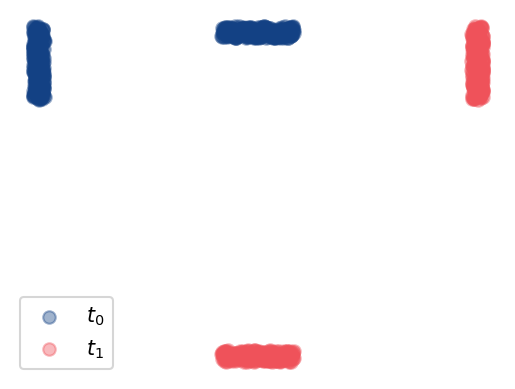

In [ ]:
plt.axis('off');
plot_marginals(t_dataset.get_marginals())

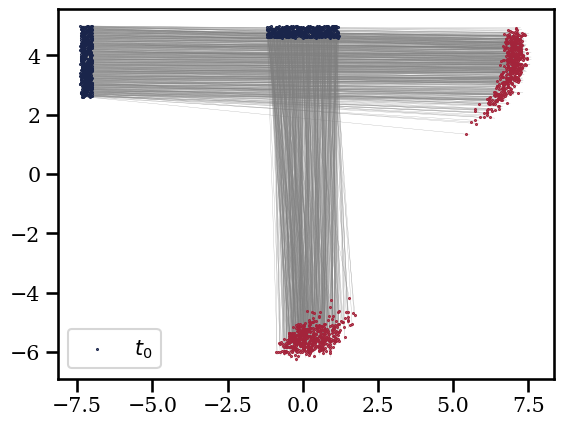

In [ ]:
#plt.axis("off")
#plt.axis("equal")
t_sampled = t_dataset.sample(samples_num=1000, trials_num=50)
if len(t_sampled.shape) == 4:
    plot_multiple_marginals(t_sampled[:,:,:,0], skip_step=99, labels=[r"$t_0$", r"$t_1$"], alpha=1)
    plot_matchings(*t_sampled[:,:,:,0][[0,-1]])
else:
    plot_multiple_marginals(t_sampled, skip_step=99, labels=[r"$t_0$", r"$t_1$"], alpha=1)
    plot_matchings(*t_sampled[[0,-1]])
export_fig("fig_sb_align_t_match")

K=1


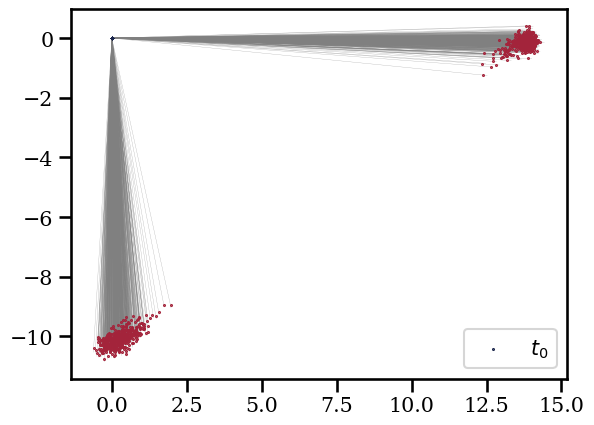

K=2


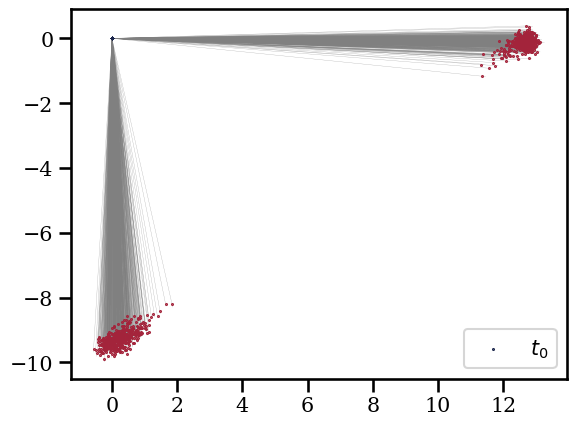

K=3


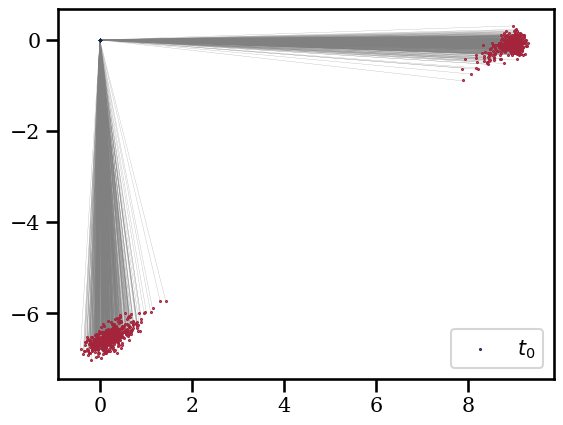

K=4


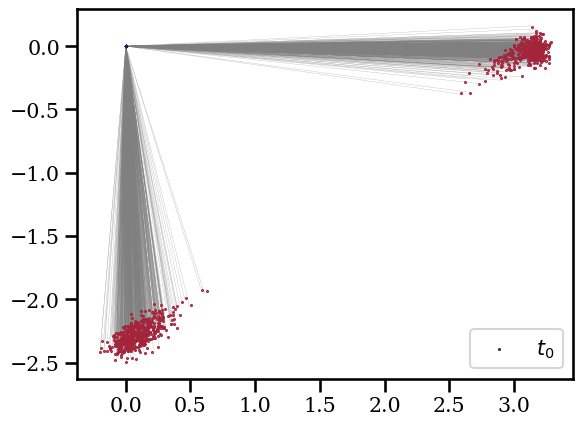

K=5


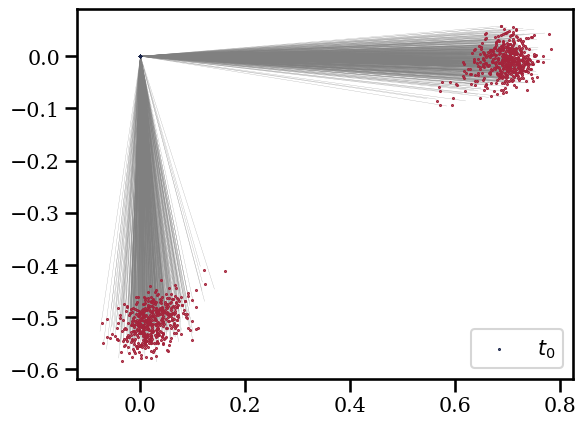

In [ ]:
if K> 0:
    for k in range(K):
        #plt.axis("off")
        #plt.axis("equal")
        print(f'K={k+1}')
        plot_multiple_marginals(t_sampled[:,:,:,k+1], skip_step=99, labels=[r"$t_0$", r"$t_1$"], alpha=1)
        plot_matchings(*t_sampled[:,:,:,k+1][[0,-1]])
        plt.show()
        plt.close()

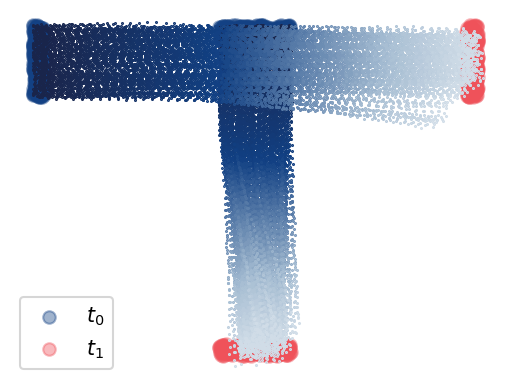

In [ ]:
plt.axis("off")
plt.axis("equal")
plot_marginals(t_dataset.get_marginals())
t_sampled = t_dataset.sample(trials_num=50)
if len(t_sampled.shape) == 4:
    t_sampled = t_sampled[:,:,:,0]
plot_multiple_marginals(t_sampled, skip_step=2)
export_fig("fig_sb_align_t_traj")

## T dataset (inverse)

### Training

In [ ]:
AlignExperiment.run("--dataset=diagonal_matching_inverse  --h_dim=32  --n_layers=3  --n_epochs=20  --reg_weight=1.  --timestep_emb_dim=32  --diffusivity_schedule=fbb  --max_diffusivity=1. --H=0.5 --K=5 --use_drift_in_doobs=True  --activation=selu").save("t_dataset_inverse")

config {'data_dir': 'diagonal_matching_inverse', 'log_dir': '../reproducibility/diagonal_matching_inverse/model', 'config': None, 'task': 'synthetic', 'wandb_entity': None, 'group_name': None, 'wandb_mode': 'online', 'job_type': 'dev-train', 'online': False, 'dataset': 'diagonal_matching_inverse', 'n_samples': 10000, 'train_bs': 32, 'val_bs': 8, 'transform': None, 'split_fracs': [0.8, 0.1, 0.1], 'num_workers': 1, 'in_dim': 2, 'out_dim': 2, 'timestep_emb_dim': 32, 'h_dim': 32, 'n_layers': 3, 'activation': 'selu', 'dropout_p': 0.1, 'run_name': 'qaxeilhcg', 'n_epochs': 20, 'use_grad_noise': False, 'drift_weight': 1.0, 'reg_weight': 1.0, 'reg_weight_T': 1.0, 'reg_weight_t': 1.0, 'diffusivity_schedule': 'fbb', 'max_diffusivity': 1.0, 'H': 0.5, 'K': 5, 'use_drift_in_doobs': True, 'optim_name': 'adamw', 'lr': 0.001, 'weight_decay': 0.001, 'grad_clip_value': 10.0, 'scheduler': 'plateau', 'scheduler_mode': 'min', 'scheduler_patience': 10, 'ema_decay_rate': 0.999, 'log_every': 1000, 'eval_every'

### Inference

In [ ]:
t_dataset_inverse = AlignExperiment.load("t_dataset_inverse")

Args: {'data_dir': 'diagonal_matching_inverse', 'log_dir': '../reproducibility/diagonal_matching_inverse/model', 'config': None, 'task': 'synthetic', 'wandb_entity': None, 'group_name': None, 'wandb_mode': 'online', 'job_type': 'dev-train', 'online': False, 'dataset': 'diagonal_matching_inverse', 'n_samples': 10000, 'train_bs': 32, 'val_bs': 8, 'transform': None, 'split_fracs': [0.8, 0.1, 0.1], 'num_workers': 1, 'in_dim': 2, 'out_dim': 2, 'timestep_emb_dim': 32, 'h_dim': 32, 'n_layers': 3, 'activation': 'selu', 'dropout_p': 0.1, 'run_name': 'qaxeilhcg', 'n_epochs': 20, 'use_grad_noise': False, 'drift_weight': 1.0, 'reg_weight': 1.0, 'reg_weight_T': 1.0, 'reg_weight_t': 1.0, 'diffusivity_schedule': 'fbb', 'max_diffusivity': 1.0, 'H': 0.5, 'K': 5, 'use_drift_in_doobs': True, 'optim_name': 'adamw', 'lr': 0.001, 'weight_decay': 0.001, 'grad_clip_value': 10.0, 'scheduler': 'plateau', 'scheduler_mode': 'min', 'scheduler_patience': 10, 'ema_decay_rate': 0.999, 'log_every': 1000, 'eval_every':

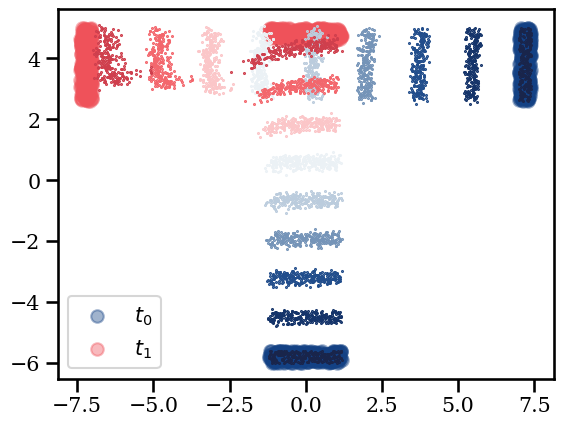

In [ ]:
#plt.axis('off');
plot_marginals(t_dataset_inverse.get_marginals())
samples = t_dataset_inverse.sample(trials_num=50)
if len(samples.shape) == 4:
    plot_multiple_marginals(samples[:,:,:,0], skip_step=12)
else:
    plot_multiple_marginals(samples, skip_step=12)

K=1


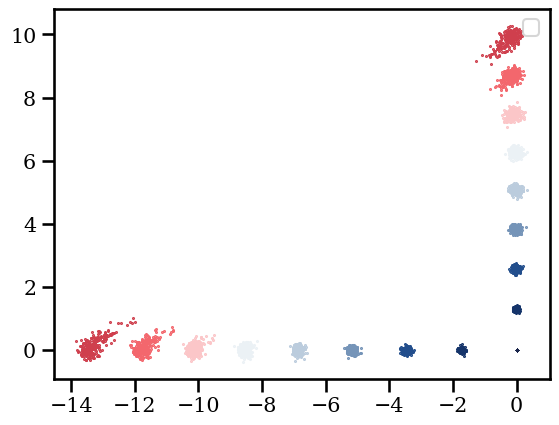

K=2


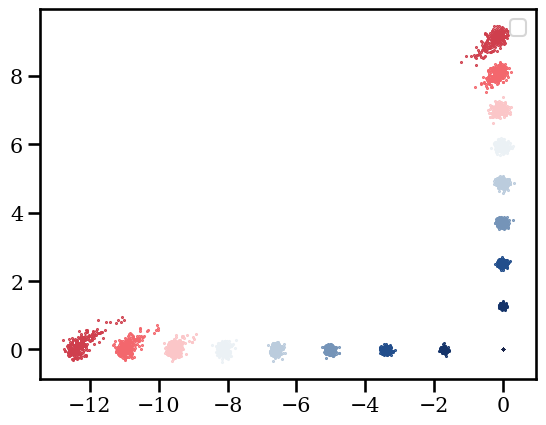

K=3


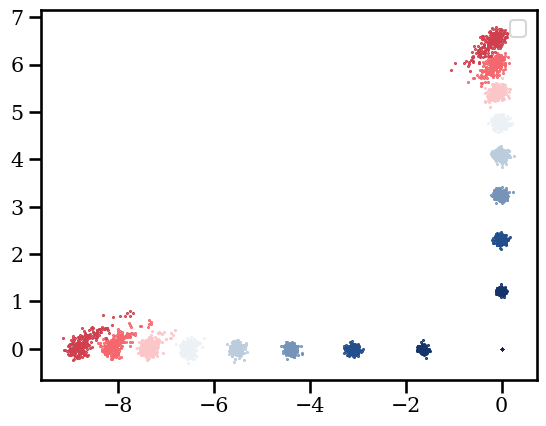

K=4


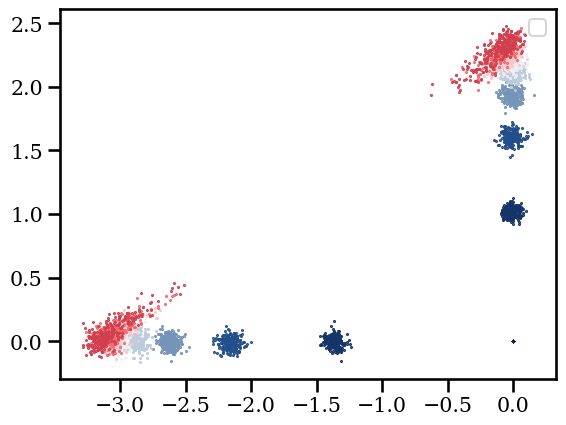

K=5


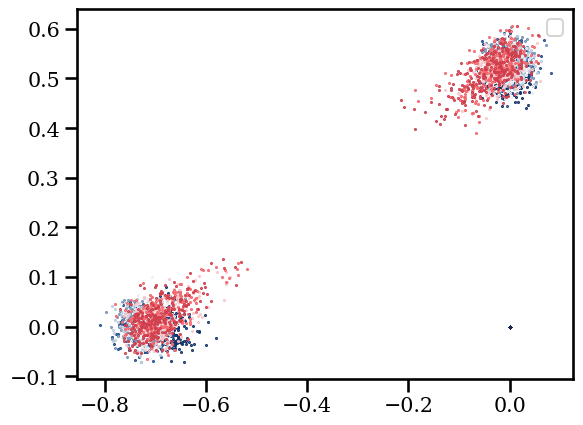

In [ ]:
if K>0:
    for k in range(K):
        print(f'K={k+1}')
        plot_multiple_marginals(samples[:,:,:,k+1], skip_step=12)
        plt.show()
        plt.close()

In [ ]:
common_marginals = t_dataset.get_marginals()

NotImplementedError: Module [FractionalSchrödingerBridge] is missing the required "forward" function

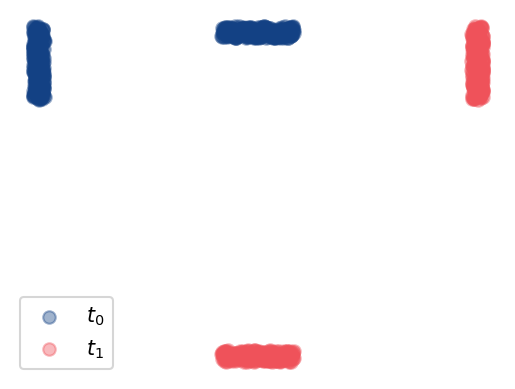

In [ ]:
plt.axis('off');
plot_marginals(common_marginals)
if len(samples.shape) == 4:
    sample = sample_inverse(t_dataset_inverse, input_data=common_marginals['initial'].to(DEVICE), trials_num=20)
    plot_multiple_marginals(mix_trajs(t_dataset.sample(input_data=common_marginals['initial'].to(DEVICE), trials_num=50), sample[:,:,:,0]), skip_step=12)
else:
    plot_multiple_marginals(mix_trajs(t_dataset.sample(input_data=common_marginals['initial'].to(DEVICE), trials_num=50), sample_inverse(t_dataset_inverse, input_data=common_marginals['initial'].to(DEVICE), trials_num=20)), skip_step=12)

In [ ]:
samples = t_dataset_inverse.sample(trials_num=50)